In [1]:
"""
Enhanced Stress Tensor Analysis with Mohr's Circle and Yield Surfaces
Python Implementation
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Polygon
from mpl_toolkits.mplot3d import Axes3D
from dataclasses import dataclass
from typing import Tuple

plt.style.use('seaborn-v0_8-darkgrid')

STRESS TENSOR ANALYSIS

Original Stress Tensor:
[[100.  20.  30.]
 [ 20.  80.  40.]
 [ 30.  40.  60.]]


Principal Stresses:
  σ1 = 140.79 MPa
  σ2 = 72.60 MPa
  σ3 = 26.61 MPa


Principal Directions:
[[ 0.65212944  0.73480651 -0.18651164]
 [ 0.55465417 -0.63016687 -0.5433677 ]
 [ 0.51680358 -0.25089662  0.81851386]]


Stress Invariants:
  I₁ = 240.00
  I₂ = 15900.00
  I₃ = 272000.00


Von Mises Equivalent Stress:
  σᵥₘ = 99.50 MPa

Maximum Shear Stress:
  τₘₐₓ = 57.09 MPa



/var/folders/x9/djdgrb394w54w15bzxcsv3jm0000gn/T/ipykernel_16978/2622671531.py:129: UserWarning: Glyph 8345 (\N{LATIN SUBSCRIPT SMALL LETTER N}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/x9/djdgrb394w54w15bzxcsv3jm0000gn/T/ipykernel_16978/2622671531.py:129: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/x9/djdgrb394w54w15bzxcsv3jm0000gn/T/ipykernel_16978/2622671531.py:129: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/x9/djdgrb394w54w15bzxcsv3jm0000gn/T/ipykernel_16978/2622671531.py:129: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/x9/djdgrb394w54w15bzxcsv3jm0000gn/T/ipykernel_16978/2622671531.py:129: UserWarning: Glyph 8344 (\N{LATIN SUBSCRIPT SMALL LETTER M}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/x9/djdgrb394w54w15bzxcsv3jm0000gn/T/ipykernel_16978/2622671531.py:

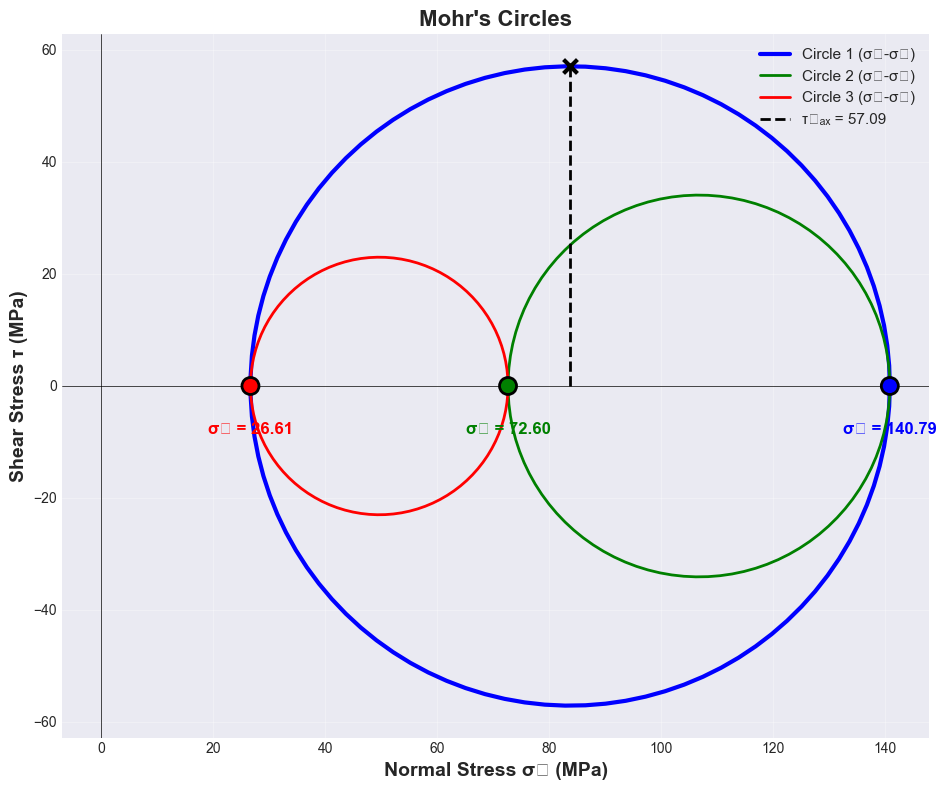

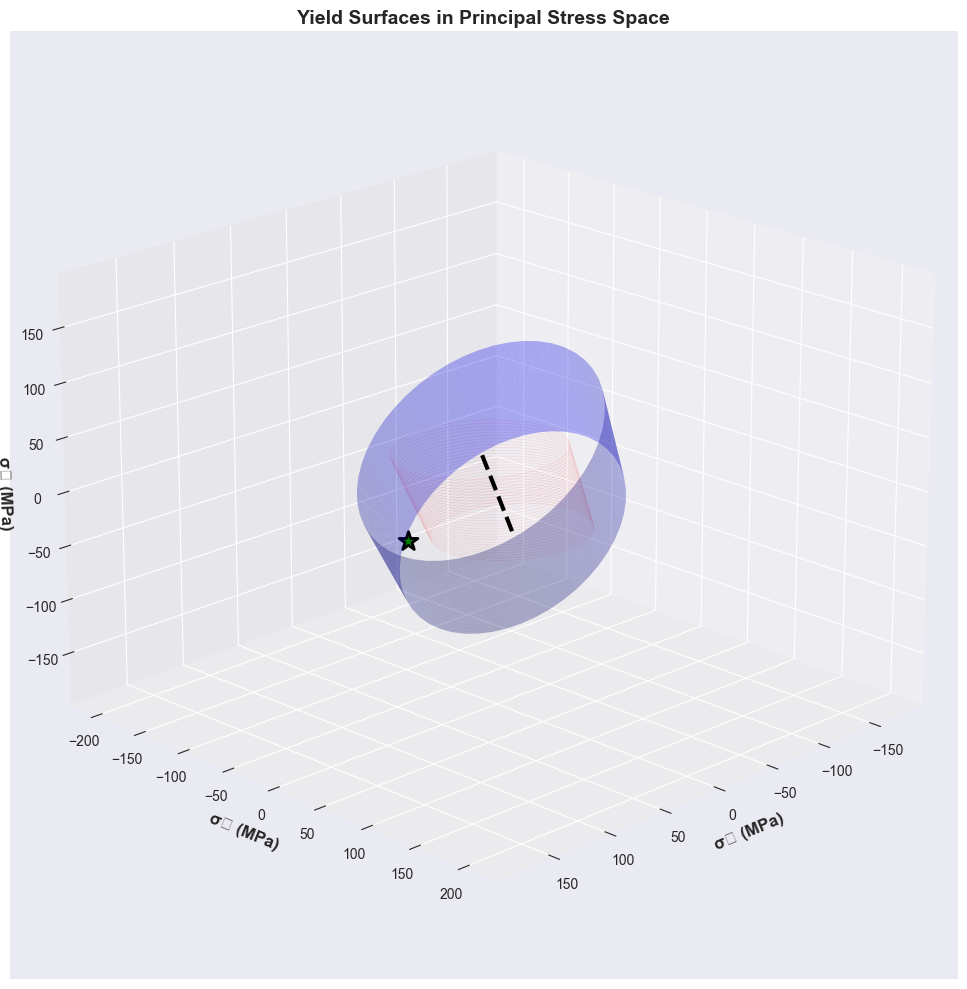

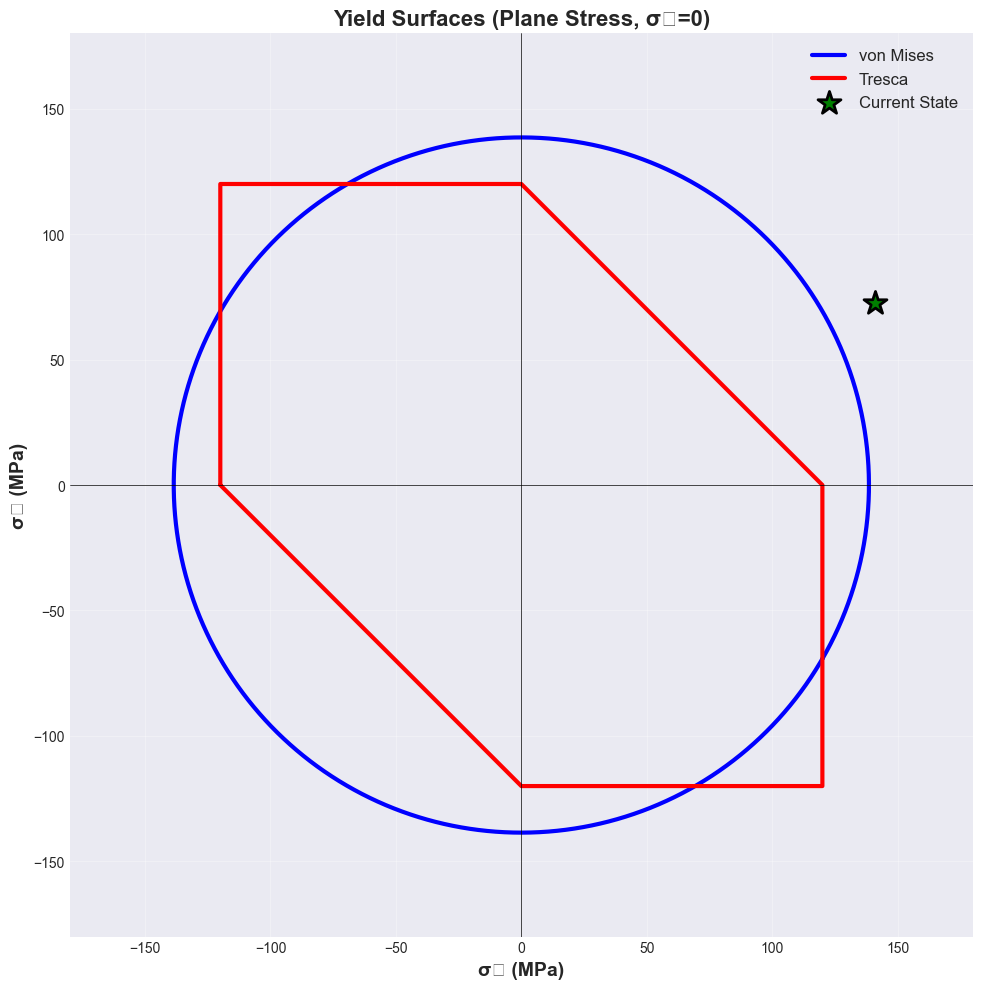

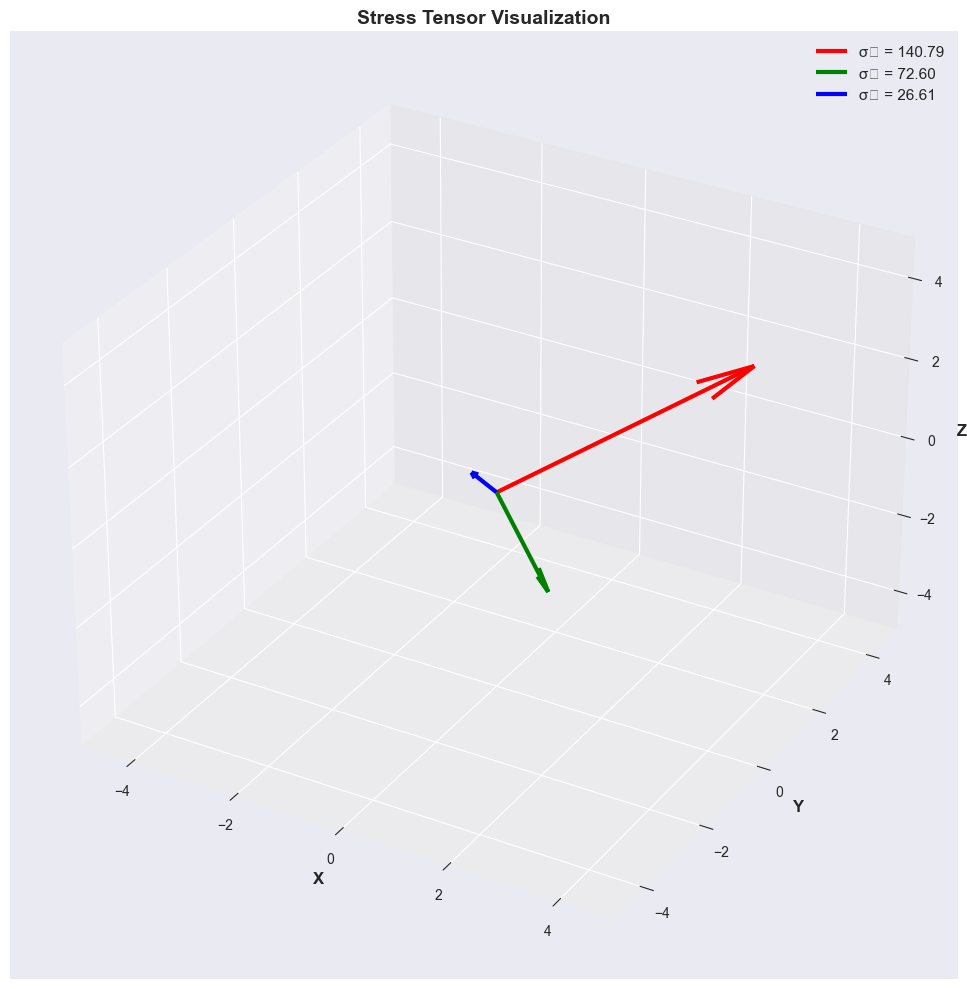


✓ All visualizations complete!
✓ Figures saved as PNG files


In [2]:

# ============================================================================
# STRESS TENSOR CLASS
# ============================================================================

@dataclass
class StressTensor:
    """A 3D stress tensor represented as a symmetric 3×3 matrix."""
    sigma: np.ndarray
    
    def __post_init__(self):
        assert self.sigma.shape == (3, 3), "Stress tensor must be 3×3"
        assert np.allclose(self.sigma, self.sigma.T), "Stress tensor must be symmetric"
    
    @classmethod
    def from_components(cls, sigma_xx, sigma_yy, sigma_zz, tau_xy, tau_xz, tau_yz):
        """Create stress tensor from components."""
        sigma = np.array([
            [sigma_xx, tau_xy, tau_xz],
            [tau_xy, sigma_yy, tau_yz],
            [tau_xz, tau_yz, sigma_zz]
        ])
        return cls(sigma)

# ============================================================================
# PRINCIPAL STRESS CALCULATIONS
# ============================================================================

def principal_stresses(stress: StressTensor) -> Tuple[np.ndarray, np.ndarray]:
    """
    Calculate principal stresses and their directions.
    
    Returns:
        eigenvalues: Principal stresses sorted in descending order (σ₁ ≥ σ₂ ≥ σ₃)
        eigenvectors: Principal directions
    """
    eigenvalues, eigenvectors = np.linalg.eig(stress.sigma)
    # Sort in descending order
    idx = np.argsort(eigenvalues)[::-1]
    return eigenvalues[idx], eigenvectors[:, idx]

def stress_invariants(stress: StressTensor) -> Tuple[float, float, float]:
    """Calculate stress tensor invariants I₁, I₂, I₃."""
    sigma = stress.sigma
    I1 = np.trace(sigma)
    I2 = 0.5 * (np.trace(sigma)**2 - np.trace(sigma @ sigma))
    I3 = np.linalg.det(sigma)
    return I1, I2, I3

def deviatoric_stress(stress: StressTensor) -> StressTensor:
    """Calculate deviatoric stress tensor."""
    p = np.trace(stress.sigma) / 3  # Mean stress
    return StressTensor(stress.sigma - p * np.eye(3))

def von_mises_stress(stress: StressTensor) -> float:
    """Calculate von Mises equivalent stress."""
    s = deviatoric_stress(stress).sigma
    return np.sqrt(1.5 * np.sum(s**2))

# ============================================================================
# MOHR'S CIRCLE VISUALIZATION
# ============================================================================

def plot_mohrs_circles(stress: StressTensor, figsize=(10, 8)):
    """Plot all three Mohr's circles for the given stress state."""
    # Get principal stresses
    sigma_principals, _ = principal_stresses(stress)
    sigma_1, sigma_2, sigma_3 = sigma_principals
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Generate circles
    theta = np.linspace(0, 2*np.pi, 100)
    
    # Circle 1: σ₁-σ₃ (largest circle)
    R1 = (sigma_1 - sigma_3) / 2
    center1 = (sigma_1 + sigma_3) / 2
    sigma_n1 = center1 + R1 * np.cos(theta)
    tau_1 = R1 * np.sin(theta)
    
    # Circle 2: σ₁-σ₂
    R2 = (sigma_1 - sigma_2) / 2
    center2 = (sigma_1 + sigma_2) / 2
    sigma_n2 = center2 + R2 * np.cos(theta)
    tau_2 = R2 * np.sin(theta)
    
    # Circle 3: σ₂-σ₃
    R3 = (sigma_2 - sigma_3) / 2
    center3 = (sigma_2 + sigma_3) / 2
    sigma_n3 = center3 + R3 * np.cos(theta)
    tau_3 = R3 * np.sin(theta)
    
    # Plot circles
    ax.plot(sigma_n1, tau_1, 'b-', linewidth=3, label=f'Circle 1 (σ₁-σ₃)')
    ax.plot(sigma_n2, tau_2, 'g-', linewidth=2, label=f'Circle 2 (σ₁-σ₂)')
    ax.plot(sigma_n3, tau_3, 'r-', linewidth=2, label=f'Circle 3 (σ₂-σ₃)')
    
    # Mark principal stresses
    ax.scatter([sigma_1, sigma_2, sigma_3], [0, 0, 0], 
               s=150, c=['blue', 'green', 'red'], 
               marker='o', zorder=5, edgecolors='black', linewidth=2)
    
    # Annotations
    offset = R1 * 0.15
    ax.annotate(f'σ₁ = {sigma_1:.2f}', (sigma_1, -offset), 
                fontsize=12, ha='center', color='blue', fontweight='bold')
    ax.annotate(f'σ₂ = {sigma_2:.2f}', (sigma_2, -offset), 
                fontsize=12, ha='center', color='green', fontweight='bold')
    ax.annotate(f'σ₃ = {sigma_3:.2f}', (sigma_3, -offset), 
                fontsize=12, ha='center', color='red', fontweight='bold')
    
    # Maximum shear stress
    tau_max = (sigma_1 - sigma_3) / 2
    ax.plot([center1, center1], [0, tau_max], 'k--', linewidth=2, 
            label=f'τₘₐₓ = {tau_max:.2f}')
    ax.scatter([center1], [tau_max], s=100, c='black', marker='x', 
               zorder=5, linewidth=3)
    
    # Formatting
    ax.set_xlabel('Normal Stress σₙ (MPa)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Shear Stress τ (MPa)', fontsize=14, fontweight='bold')
    ax.set_title("Mohr's Circles", fontsize=16, fontweight='bold')
    ax.legend(fontsize=11, loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    
    plt.tight_layout()
    return fig, ax

# ============================================================================
# YIELD SURFACE VISUALIZATION (3D Principal Stress Space)
# ============================================================================

def plot_yield_surfaces_3d(stress: StressTensor, sigma_yield=100.0, figsize=(12, 10)):
    """Plot von Mises and Tresca yield surfaces in 3D principal stress space."""
    # Get principal stresses
    sigma_principals, _ = principal_stresses(stress)
    
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')
    
    # Von Mises surface (cylinder around hydrostatic axis)
    theta = np.linspace(0, 2*np.pi, 50)
    z = np.linspace(-1.5*sigma_yield, 1.5*sigma_yield, 50)
    Theta, Z = np.meshgrid(theta, z)
    
    r_vm = sigma_yield * np.sqrt(2/3)
    sigma_1_vm = r_vm * np.cos(Theta) * np.cos(np.pi/4) + Z/np.sqrt(3)
    sigma_2_vm = r_vm * np.sin(Theta) + Z/np.sqrt(3)
    sigma_3_vm = -r_vm * np.cos(Theta) * np.cos(np.pi/4) + Z/np.sqrt(3)
    
    # Plot von Mises surface
    ax.plot_surface(sigma_1_vm, sigma_2_vm, sigma_3_vm, 
                    alpha=0.3, color='blue', label='von Mises')
    
    # Tresca surface (hexagonal prism) - simplified representation
    hex_angles = np.linspace(0, 2*np.pi, 7)
    z_tresca = np.linspace(-1.5*sigma_yield, 1.5*sigma_yield, 30)
    
    for i in range(len(hex_angles)-1):
        t = np.linspace(hex_angles[i], hex_angles[i+1], 10)
        for zz in z_tresca:
            s1 = sigma_yield/2 * np.cos(t) + zz/np.sqrt(3)
            s2 = sigma_yield/2 * np.sin(t) + zz/np.sqrt(3)
            s3 = np.full_like(s1, zz/np.sqrt(3))
            ax.plot(s1, s2, s3, 'r-', alpha=0.1, linewidth=0.5)
    
    # Hydrostatic axis
    h_line = np.linspace(-1.5*sigma_yield, 1.5*sigma_yield, 50)
    ax.plot(h_line/np.sqrt(3), h_line/np.sqrt(3), h_line/np.sqrt(3),
            'k--', linewidth=3, label='Hydrostatic Axis')
    
    # Current stress state
    ax.scatter(*sigma_principals, s=200, c='green', marker='*', 
               edgecolors='black', linewidth=2, label='Current State', zorder=10)
    
    # Labels and formatting
    ax.set_xlabel('σ₁ (MPa)', fontsize=12, fontweight='bold')
    ax.set_ylabel('σ₂ (MPa)', fontsize=12, fontweight='bold')
    ax.set_zlabel('σ₃ (MPa)', fontsize=12, fontweight='bold')
    ax.set_title('Yield Surfaces in Principal Stress Space', 
                 fontsize=14, fontweight='bold')
    ax.view_init(elev=20, azim=45)
    
    plt.tight_layout()
    return fig, ax

# ============================================================================
# 2D YIELD SURFACE VISUALIZATION (Plane Stress)
# ============================================================================

def plot_yield_surfaces_2d(stress: StressTensor, sigma_yield=100.0, figsize=(10, 10)):
    """Plot von Mises and Tresca yield surfaces for plane stress (σ₃ = 0)."""
    fig, ax = plt.subplots(figsize=figsize)
    
    # Von Mises criterion for plane stress: σ₁² - σ₁σ₂ + σ₂² = σ_yield²
    theta = np.linspace(0, 2*np.pi, 500)
    sigma_1_vm = sigma_yield * np.cos(theta - np.pi/6) * np.sqrt(4/3)
    sigma_2_vm = sigma_yield * np.sin(theta - np.pi/6) * np.sqrt(4/3)
    
    ax.plot(sigma_1_vm, sigma_2_vm, 'b-', linewidth=3, label='von Mises')
    
    # Tresca criterion (hexagon)
    tresca_points = np.array([
        [-sigma_yield, 0],
        [0, -sigma_yield],
        [sigma_yield, -sigma_yield],
        [sigma_yield, 0],
        [0, sigma_yield],
        [-sigma_yield, sigma_yield],
        [-sigma_yield, 0]
    ])
    
    ax.plot(tresca_points[:, 0], tresca_points[:, 1], 
            'r-', linewidth=3, label='Tresca')
    
    # Current stress state
    sigma_principals, _ = principal_stresses(stress)
    ax.scatter(sigma_principals[0], sigma_principals[1], 
               s=300, c='green', marker='*', 
               edgecolors='black', linewidth=2, 
               label='Current State', zorder=10)
    
    # Formatting
    ax.set_xlabel('σ₁ (MPa)', fontsize=14, fontweight='bold')
    ax.set_ylabel('σ₂ (MPa)', fontsize=14, fontweight='bold')
    ax.set_title('Yield Surfaces (Plane Stress, σ₃=0)', 
                 fontsize=16, fontweight='bold')
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    
    # Set limits
    lim = 1.5 * sigma_yield
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    
    plt.tight_layout()
    return fig, ax

# ============================================================================
# STRESS TENSOR 3D VISUALIZATION
# ============================================================================

def plot_stress_tensor_3d(stress: StressTensor, figsize=(12, 10)):
    """Visualize the stress tensor acting on the principal axes."""
    # Get principal stresses and directions
    sigma_principals, directions = principal_stresses(stress)
    
    # Scale factor for visualization
    scale = np.max(np.abs(sigma_principals)) / 5
    
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')
    
    # Colors and labels
    colors = ['red', 'green', 'blue']
    labels = [f'σ₁ = {sigma_principals[0]:.2f}',
              f'σ₂ = {sigma_principals[1]:.2f}',
              f'σ₃ = {sigma_principals[2]:.2f}']
    
    # Plot principal stress directions
    for i in range(3):
        direction = directions[:, i]
        magnitude = sigma_principals[i] / scale
        
        # Plot arrow
        ax.quiver(0, 0, 0, 
                  direction[0]*magnitude, 
                  direction[1]*magnitude, 
                  direction[2]*magnitude,
                  color=colors[i], 
                  arrow_length_ratio=0.2,
                  linewidth=3,
                  label=labels[i])
    
    # Formatting
    ax.set_xlabel('X', fontsize=12, fontweight='bold')
    ax.set_ylabel('Y', fontsize=12, fontweight='bold')
    ax.set_zlabel('Z', fontsize=12, fontweight='bold')
    ax.set_title('Stress Tensor Visualization', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    
    # Set equal aspect ratio
    max_range = np.max(np.abs(sigma_principals)) / scale
    ax.set_xlim([-max_range, max_range])
    ax.set_ylim([-max_range, max_range])
    ax.set_zlim([-max_range, max_range])
    
    plt.tight_layout()
    return fig, ax

# ============================================================================
# EXAMPLE USAGE
# ============================================================================

if __name__ == "__main__":
    # Define stress tensor
    stress = StressTensor.from_components(
        sigma_xx=100.0, sigma_yy=80.0, sigma_zz=60.0,
        tau_xy=20.0, tau_xz=30.0, tau_yz=40.0
    )
    
    print("="*70)
    print("STRESS TENSOR ANALYSIS")
    print("="*70)
    print("\nOriginal Stress Tensor:")
    print(stress.sigma)
    
    # Calculate principal stresses
    sigma_principals, directions = principal_stresses(stress)
    print("\n\nPrincipal Stresses:")
    for i, sigma_i in enumerate(sigma_principals, 1):
        print(f"  σ{i} = {sigma_i:.2f} MPa")
    
    print("\n\nPrincipal Directions:")
    print(directions)
    
    # Calculate invariants
    I1, I2, I3 = stress_invariants(stress)
    print("\n\nStress Invariants:")
    print(f"  I₁ = {I1:.2f}")
    print(f"  I₂ = {I2:.2f}")
    print(f"  I₃ = {I3:.2f}")
    
    # Von Mises stress
    sigma_vm = von_mises_stress(stress)
    print("\n\nVon Mises Equivalent Stress:")
    print(f"  σᵥₘ = {sigma_vm:.2f} MPa")
    
    # Maximum shear stress
    tau_max = (sigma_principals[0] - sigma_principals[2]) / 2
    print("\nMaximum Shear Stress:")
    print(f"  τₘₐₓ = {tau_max:.2f} MPa")
    
    print("\n" + "="*70)
    
    # Create all visualizations
    sigma_yield = 120.0  # Yield stress in MPa
    
    # 1. Mohr's Circles
    fig1, ax1 = plot_mohrs_circles(stress)
    plt.savefig('mohrs_circles.png', dpi=300, bbox_inches='tight')
    
    # 2. 3D Yield Surfaces
    fig2, ax2 = plot_yield_surfaces_3d(stress, sigma_yield)
    plt.savefig('yield_surfaces_3d.png', dpi=300, bbox_inches='tight')
    
    # 3. 2D Yield Surfaces
    fig3, ax3 = plot_yield_surfaces_2d(stress, sigma_yield)
    plt.savefig('yield_surfaces_2d.png', dpi=300, bbox_inches='tight')
    
    # 4. Stress Tensor 3D
    fig4, ax4 = plot_stress_tensor_3d(stress)
    plt.savefig('stress_tensor_3d.png', dpi=300, bbox_inches='tight')
    
    plt.show()
    
    print("\n✓ All visualizations complete!")
    print("✓ Figures saved as PNG files")